In [57]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import re
# Scikit 
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import ElasticNet
#Pytorch 
import torchvision
import torchaudio
import torch.nn as nn
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
# show the progress bar while priting
from tqdm import tqdm

import copy
import os
import xgboost as xgb



In [58]:
df = pd.read_csv("/Users/Thomas/Desktop/Master Thesis/Data/contracts_with_label.csv", 
low_memory=False)

In [59]:
df.head()

,Unnamed: 0.1,Unnamed: 0,contract_id,observation_year,contract_number,contract_name,contract_status,terminated,term_type,start_date,...,news_positive_count,news_neutral_count,news_avg_sentiment_score,news_avg_relevance_score,news_max_relevance_score,news_negative_ratio,news_has_high_relevance_negative_news,contracts_per_supplier,renegotiation_prob,target_renegotiate
0,0,0,9675,2018,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
1,1,1,9675,2019,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
2,2,2,9675,2020,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
3,3,3,9675,2021,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0
4,4,4,9675,2022,9675,Bioreliance_Master_2018_MSA,published,False,fixed,2018-05-21 00:00:00+00:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.374397,0


In [60]:
print(df.shape)
print(f"Number of unique contracts: {df['contract_id'].nunique()}")
print(df.info())

(9201, 153)
Number of unique contracts: 2209
<class 'pandas.DataFrame'>
RangeIndex: 9201 entries, 0 to 9200
Columns: 153 entries, Unnamed: 0.1 to target_renegotiate
dtypes: bool(1), float64(94), int64(15), object(1), str(42)
memory usage: 10.7+ MB
None


# Number of unique contracts per department

In [61]:

contracts_per_department = (
    df
    .groupby("department", dropna=False)["contract_id"]
    .nunique()
    .reset_index(name="unique_contract_count")
    .sort_values("unique_contract_count", ascending=False)
)

print(contracts_per_department)

                                 department  unique_contract_count
12                                      NaN                    607
7                        Packaging Material                    289
9                    Raw Materials & Energy                    281
4                  Drug Product Outsourcing                    275
8   Quality, Production Services & Supplies                    215
5                Drug Substance Outsourcing                    163
3                         Devices & Needles                    158
6                                 Logistics                     94
2              Bioprocessing and Excipients                     59
0          Alliance, Acquisitions & PPM CoE                     35
1             Bioprocessing & Raw Materials                     22
10                Strategic Sourcing US�Hub                      9
11     Strategy, Sourcing & Negotiation CoE                      2


# Rows pr. Department

In [62]:
rows_per_department = (
    df
    .groupby("department", dropna=False)
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

print(rows_per_department)

                                 department  row_count
12                                      NaN       3050
9                    Raw Materials & Energy       1555
7                        Packaging Material       1272
8   Quality, Production Services & Supplies       1044
3                         Devices & Needles        586
4                  Drug Product Outsourcing        539
6                                 Logistics        282
0          Alliance, Acquisitions & PPM CoE        270
5                Drug Substance Outsourcing        243
2              Bioprocessing and Excipients        218
1             Bioprocessing & Raw Materials        125
10                Strategic Sourcing US�Hub         15
11     Strategy, Sourcing & Negotiation CoE          2


# Number of unique contracts per department per year

In [63]:
contracts_per_department_year_pivot = (
    df
    .groupby(["department", "observation_year"], dropna=False)["contract_id"]
    .nunique()
    .unstack(fill_value=0)
)

print(contracts_per_department_year_pivot)

observation_year                         2015  2016  2017  2018  2019  2020  \
department                                                                    
Alliance, Acquisitions & PPM CoE           11    12    15    22    24    25   
Bioprocessing & Raw Materials               6     7     7     9     9     9   
Bioprocessing and Excipients                8     8     8    10    11    18   
Devices & Needles                           9    11    14    18    25    32   
Drug Product Outsourcing                    1     1     1     1     6    11   
Drug Substance Outsourcing                  1     2     2     2     3     4   
Logistics                                   5     5     9     9     9    10   
Packaging Material                         36    39    43    52    73    91   
Quality, Production Services & Supplies    17    22    27    44    62    81   
Raw Materials & Energy                     51    66    72    88   104   115   
Strategic Sourcing US�Hub                   0     0 

# Stage 1: Mean Predictor, Linear BaseLine, XGBoost Baseline & MLP Baseline 

In [64]:
#Use this when we have done feature engineering
# df_baseline = df_feature_engineered

df_baseline = df.copy()

Target columns

In [65]:
target_col = "renegotiation_prob"
group_col = "contract_id"

Features to drop

In [66]:
drop_cols = [
    "Unnamed: 0",
    "contract_id",
    "contract_number",
    "contract_name",
    "supplier_id",
    "supplier_number",
    "supplier_display_name",
    "moodys_bvd_id",
    "Company name Latin alphabet",
    "target_renegotiate",
    "start_date",
    "expiration_date",
]

In [67]:
feature_cols = [c for c in df_baseline.columns if c not in drop_cols + [target_col]]

X = df_baseline[feature_cols].copy()
y = df_baseline[target_col].astype(float).copy()
groups = df_baseline[group_col].copy()

Group splitting

In [68]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_val = X.iloc[val_idx].copy()

y_train = y.iloc[train_idx].copy()
y_val = y.iloc[val_idx].copy()

train_groups = groups.iloc[train_idx].copy()
val_groups = groups.iloc[val_idx].copy()

print("Train rows:", X_train.shape[0])
print("Val rows:", X_val.shape[0])
print("Train unique contracts:", train_groups.nunique())
print("Val unique contracts:", val_groups.nunique())


Train rows: 7302
Val rows: 1899
Train unique contracts: 1767
Val unique contracts: 442


Evaluation function

In [69]:
def evaluate_predictions(y_true, y_pred, model_name="model"):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({
        "model": [model_name],
        "rmse": [rmse],
        "mae": [mae],
        "r2": [r2],
        "pred_mean": [np.mean(y_pred)],
        "true_mean": [np.mean(y_true)]
    })

### Define what is numerical and categorical columns

In [70]:
numeric_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string", "str"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 104
Categorical columns: 36


### Preprocssesing

In [71]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

Creating a list to store results from baseline models

In [72]:
baseline_results_list = []

baseline_val_predictions = pd.DataFrame({
    "contract_id": val_groups.values,
    "y_true": y_val.values
})

print(baseline_val_predictions.head())

   contract_id    y_true
0         8157  0.698766
1         8157  0.698766
2         8157  0.698766
3         8157  0.696954
4         8157  0.696954


## Mean predictor

In [73]:
train_mean = y_train.mean()
y_pred_mean = np.full(shape=len(y_val), fill_value=train_mean)

results_mean = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_mean,
    model_name="Mean Predictor"
)

baseline_results_list.append(results_mean)
baseline_val_predictions["mean_predictor"] = y_pred_mean

print(results_mean)

            model      rmse       mae        r2  pred_mean  true_mean
0  Mean Predictor  0.209304  0.167898 -0.003187   0.525461   0.513663


## ElasticNet

In [74]:
elastic_net = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=42))
])

elastic_net.fit(X_train, y_train)
y_pred_enet = elastic_net.predict(X_val)

# Keep predictions within [0, 1]
y_pred_enet = np.clip(y_pred_enet, 0, 1)

results_enet = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_enet,
    model_name="Elastic Net"
)

baseline_results_list.append(results_enet)
baseline_val_predictions["elastic_net"] = y_pred_enet

print(results_enet)

         model      rmse      mae        r2  pred_mean  true_mean
0  Elastic Net  0.128211  0.10415  0.623573   0.511017   0.513663


## MLP baseline

### Transform into Matricies & Dataloaders

In [75]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

# convert sparse -> dense if needed
if hasattr(X_train_proc, "toarray"):
    X_train_proc = X_train_proc.toarray()
    X_val_proc = X_val_proc.toarray()

X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_proc, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

In [76]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

### MLP

In [77]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------------------
# Initialize model
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TabularMLP(input_dim=X_train_tensor.shape[1]).to(device)

# Soft-label binary cross-entropy on logits
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# 3. Evaluation function
# ------------------------------------------------------------
def evaluate_mlp(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits)

            preds.append(probs.cpu().numpy())
            targets.append(yb.cpu().numpy())

    preds = np.vstack(preds).ravel()
    targets = np.vstack(targets).ravel()

    avg_loss = total_loss / len(loader.dataset)
    rmse = mean_squared_error(targets, preds) ** 0.5
    mae = mean_absolute_error(targets, preds)

    return avg_loss, rmse, mae

# ------------------------------------------------------------
# 4. Training loop with early stopping
# ------------------------------------------------------------
best_val_loss = float("inf")
best_state_dict = None
patience = 5
patience_counter = 0

train_losses = []
val_losses = []
val_rmses = []
val_maes = []

n_epochs = 50

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_rmse, val_mae = evaluate_mlp(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_rmses.append(val_rmse)
    val_maes.append(val_mae)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val RMSE: {val_rmse:.4f} | "
        f"Val MAE: {val_mae:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch + 1}")
        break

# ------------------------------------------------------------
# 5. Restore best model
# ------------------------------------------------------------
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

# ------------------------------------------------------------
# 6. Save pretrained model in memory and locally
# ------------------------------------------------------------
pretrained_mlp_state_dict = copy.deepcopy(model.state_dict())

save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

mlp_model_path = os.path.join(save_dir, "mlp_pretrained.pt")
torch.save(pretrained_mlp_state_dict, mlp_model_path)

print(f"Saved pretrained MLP locally to: {mlp_model_path}")
print("Pretrained MLP also stored in memory as: pretrained_mlp_state_dict")

# ------------------------------------------------------------
# 7. Final validation predictions from best model
# ------------------------------------------------------------
model.eval()
mlp_preds = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = model(xb)
        probs = torch.sigmoid(logits)

        mlp_preds.append(probs.cpu().numpy())

y_pred_mlp = np.vstack(mlp_preds).ravel()

# ------------------------------------------------------------
# 8. Add MLP to baseline comparison
# ------------------------------------------------------------
results_mlp = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_mlp,
    model_name="MLP"
)

baseline_results_list.append(results_mlp)
baseline_val_predictions["mlp"] = y_pred_mlp

print(results_mlp)

# ------------------------------------------------------------
# 9. Store training history
# ------------------------------------------------------------
mlp_training_history = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_rmse": val_rmses,
    "val_mae": val_maes
})

mlp_history_path = os.path.join(save_dir, "mlp_training_history.csv")
mlp_training_history.to_csv(mlp_history_path, index=False)

print(f"Saved MLP training history locally to: {mlp_history_path}")
print(mlp_training_history.head())

Epoch 01 | Train Loss: 0.6545 | Val Loss: 0.6316 | Val RMSE: 0.1110 | Val MAE: 0.0870
Epoch 02 | Train Loss: 0.6312 | Val Loss: 0.6455 | Val RMSE: 0.1039 | Val MAE: 0.0814
Epoch 03 | Train Loss: 0.6274 | Val Loss: 0.6282 | Val RMSE: 0.0988 | Val MAE: 0.0742
Epoch 04 | Train Loss: 0.6246 | Val Loss: 0.6352 | Val RMSE: 0.0974 | Val MAE: 0.0736
Epoch 05 | Train Loss: 0.6221 | Val Loss: 0.6371 | Val RMSE: 0.0931 | Val MAE: 0.0680
Epoch 06 | Train Loss: 0.6202 | Val Loss: 0.6255 | Val RMSE: 0.0880 | Val MAE: 0.0623
Epoch 07 | Train Loss: 0.6188 | Val Loss: 0.6351 | Val RMSE: 0.0871 | Val MAE: 0.0602
Epoch 08 | Train Loss: 0.6177 | Val Loss: 0.6174 | Val RMSE: 0.0851 | Val MAE: 0.0580
Epoch 09 | Train Loss: 0.6167 | Val Loss: 0.6154 | Val RMSE: 0.0834 | Val MAE: 0.0554
Epoch 10 | Train Loss: 0.6156 | Val Loss: 0.6158 | Val RMSE: 0.0830 | Val MAE: 0.0555
Epoch 11 | Train Loss: 0.6161 | Val Loss: 0.6201 | Val RMSE: 0.0776 | Val MAE: 0.0520
Epoch 12 | Train Loss: 0.6146 | Val Loss: 0.6327 | Val

## XGboost

In [83]:
numeric_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_xgb, numeric_cols),
        ("cat", categorical_transformer_xgb, categorical_cols),
    ]
)

In [88]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
y_pred_xgb = np.clip(y_pred_xgb, 0, 1)

results_xgb = evaluate_predictions(
    y_true=y_val,
    y_pred=y_pred_xgb,
    model_name="XGBoost"
)

baseline_results_list.append(results_xgb)
baseline_val_predictions["xgboost"] = y_pred_xgb

print(results_xgb)

     model      rmse       mae        r2  pred_mean  true_mean
0  XGBoost  0.031107  0.008827  0.977842   0.513193   0.513663


In [89]:
# Get trained xgboost model out of pipeline
xgb_fitted = xgb_model.named_steps["model"]
xgb_preprocessor = xgb_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Build importance table
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_fitted.feature_importances_
}).sort_values("importance", ascending=False)

print(xgb_importance.head(50))

                                               feature  importance
103                        num__contracts_per_supplier    0.163487
107                               cat__term_type_fixed    0.128746
12                             num__contract_age_years    0.125614
7                                     num__expiry_year    0.097011
6                                      num__start_year    0.034094
384                    cat__supplier_country_bridge_CH    0.033293
4                               num__days_until_expiry    0.030752
405                    cat__supplier_country_bridge_SG    0.027865
1                                num__observation_year    0.026948
115     cat__payment_terms_F030 Invoice Date + 30 days    0.020241
380                    cat__supplier_country_bridge_AT    0.016264
487          cat__department_filled_Packaging Material    0.015110
465       cat__Risk level_stock_closing_price_Go ahead    0.014770
161                    cat__contract_type_Distribution    0.01

## Compare baseline predictions

In [90]:
baseline_results = pd.concat(baseline_results_list, ignore_index=True)
baseline_results = baseline_results.sort_values("mae", ascending=True).reset_index(drop=True)

print(baseline_results)
print(baseline_val_predictions.head())

            model      rmse       mae        r2  pred_mean  true_mean
0         XGBoost  0.031107  0.008827  0.977842   0.513193   0.513663
1         XGBoost  0.031107  0.008827  0.977842   0.513193   0.513663
2         XGBoost  0.031107  0.008827  0.977842   0.513193   0.513663
3         XGBoost  0.031107  0.008827  0.977842   0.513193   0.513663
4             MLP  0.070407  0.045189  0.886484   0.502249   0.513663
5     Elastic Net  0.128211  0.104150  0.623573   0.511017   0.513663
6  Mean Predictor  0.209304  0.167898 -0.003187   0.525461   0.513663
   contract_id    y_true  mean_predictor  elastic_net       mlp   xgboost
0         8157  0.698766        0.525461     0.607288  0.667001  0.698491
1         8157  0.698766        0.525461     0.577005  0.671796  0.698574
2         8157  0.698766        0.525461     0.546723  0.668601  0.698574
3         8157  0.696954        0.525461     0.505982  0.661118  0.698764
4         8157  0.696954        0.525461     0.475699  0.677140  0.699

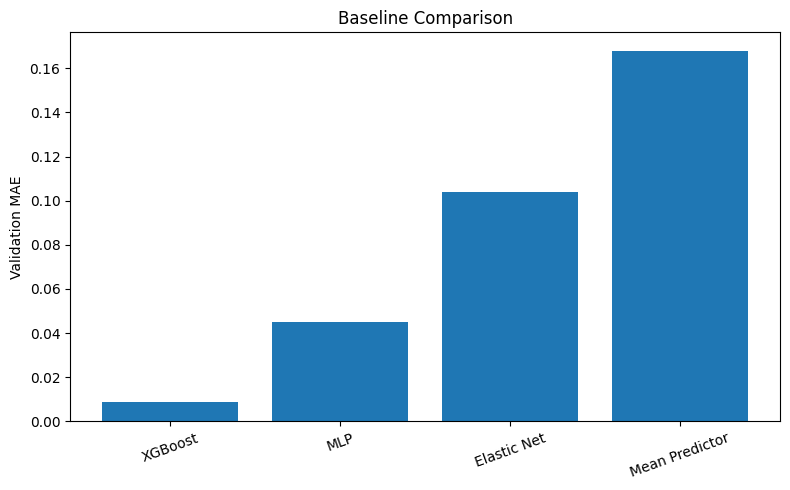

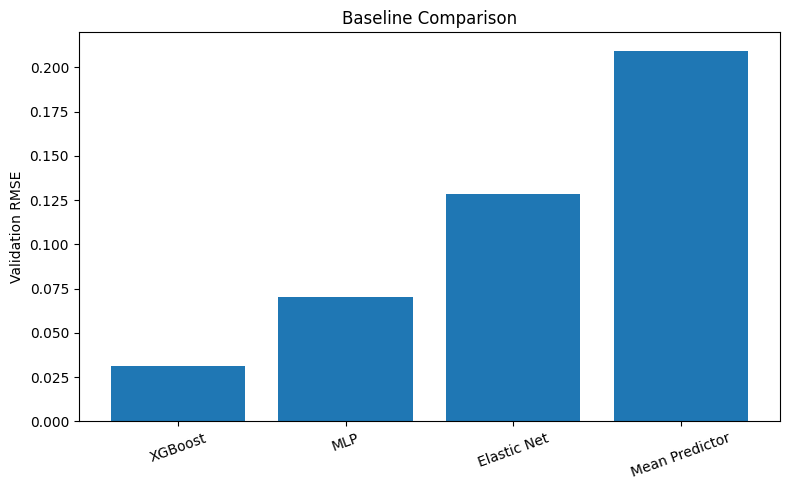

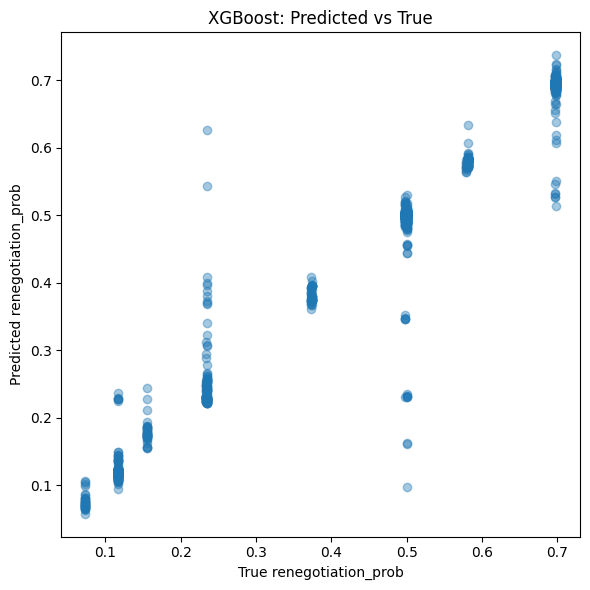

In [87]:
plot_df = baseline_results.sort_values("mae", ascending=True)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["mae"])
plt.ylabel("Validation MAE")
plt.title("Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["rmse"])
plt.ylabel("Validation RMSE")
plt.title("Baseline Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred_xgb, alpha=0.4)
plt.xlabel("True renegotiation_prob")
plt.ylabel("Predicted renegotiation_prob")
plt.title("XGBoost: Predicted vs True")
plt.tight_layout()
plt.show()

# Stage 2: Pre-trained MLP+finetuning, Pretrained MLP + MAML or FOMAML, MALP on logistics & Pooled Gold label MLP  - Test also with XGBoost on gold labels

	•	does few-shot adaptation help?
	•	does MAML beat plain fine-tuning?
XGboost?

	•	maybe MAML beats fine-tuning
	•	but does it beat a strong non-neural tabular baseline?


	• Stage 1: Who best learns the weak-label signal?
	•	Stage 2: Does meta-learning improve target-department adaptation over ordinary transfer learning?
	•	Gold-label benchmark question: How does the neural adaptation framework compare to a strong tabular non-meta model like XGBoost?


Figure X. Few-shot adaptation to the Logistics department.

(A) Support/query split at contract level.

(B) Distribution of predicted renegotiation scores on the Logistics query set before and after adaptation.

(C) Ranked query contracts with true gold labels highlighted, comparing fine-tuning and MAML.

(D) Precision@K across competing methods, showing the effectiveness of top-K contract prioritization.